## 1. Cai Dat Dependencies

In [1]:
import torch;
print(torch.__version__);
print(torch.version.cuda);
print(torch.cuda.is_available());
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else "No GPU available"

2.7.1+cu128
12.8
True
NVIDIA GeForce RTX 4090


In [2]:
# Cài đặt các thư viện cần thiết
# %pip install torch torchvision transformers accelerate pillow einops timm gradio sentencepiece safetensors requests matplotlib

In [3]:
# Import các thư viện
import torch
import torch.nn as nn
from PIL import Image
from transformers import AutoModel, AutoModelForCausalLM, AutoImageProcessor, AutoTokenizer
from dataclasses import dataclass
from typing import Optional, List
import requests
from io import BytesIO

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4090
VRAM: 23.5 GB


---
## 1.5. Demo Dataset Structure

Xem cau truc du lieu truoc khi bat dau.

Total training samples: 2876

SAMPLE DATA STRUCTURE:

Sample keys: ['comment', 'list_img', 'text_label', 'text_img_label', 'label_each_img', 'text_one_img_label']

Comment: 💯 khách sạn kh có gì để chê 🤣

Image files: ['image_6670_0.png', 'image_6670_1.png']

Labels (text_img_label): ['Facilities#Positive', 'Public_area#Positive']

Image path: datasets/image/image_6670_0.png


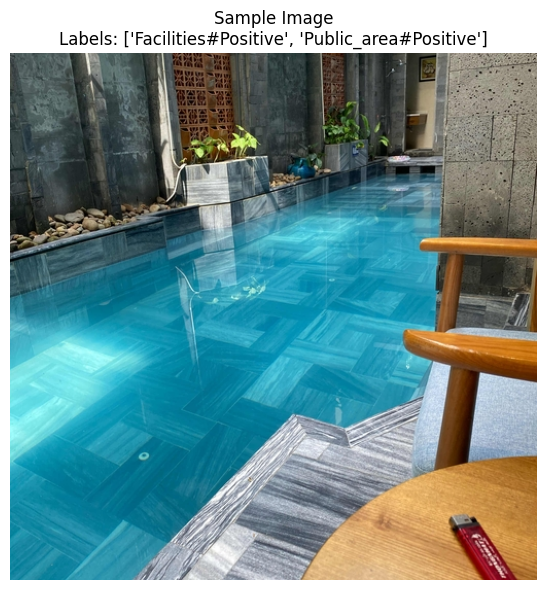


Image size: (512, 512)
Image mode: RGB

LABEL DISTRIBUTION:

Total labels: 8650
Unique labels: 18

Top 10 most common labels:
  Service#Positive                          1723 (19.9%)
  Public_area#Positive                      1509 (17.4%)
  Room#Positive                             1497 (17.3%)
  Location#Positive                          689 (8.0%)
  Facilities#Positive                        557 (6.4%)
  Public_area#Neutral                        519 (6.0%)
  Food#Positive                              444 (5.1%)
  Room#Neutral                               345 (4.0%)
  Room#Negative                              307 (3.5%)
  Facilities#Neutral                         208 (2.4%)


In [4]:
# ============================================
# DEMO DATASET STRUCTURE
# ============================================

import json
import os
from PIL import Image
import matplotlib.pyplot as plt

# Duong dan dataset
DATA_DIR = "datasets"
IMAGE_DIR = os.path.join(DATA_DIR, "image")

# Load 1 sample tu train.json
with open(os.path.join(DATA_DIR, "train.json"), 'r', encoding='utf-8') as f:
    train_data = json.load(f)

print(f"Total training samples: {len(train_data)}")
print("\n" + "=" * 80)
print("SAMPLE DATA STRUCTURE:")
print("=" * 80)

# Hien thi 1 sample
sample = train_data[0]
print(f"\nSample keys: {list(sample.keys())}")
print(f"\nComment: {sample.get('comment', 'N/A')}")
print(f"\nImage files: {sample.get('list_img', [])}")
print(f"\nLabels (text_img_label): {sample.get('text_img_label', [])}")

# Load va hien thi anh dau tien (neu co)
if sample.get('list_img') and len(sample['list_img']) > 0:
    img_path = os.path.join(IMAGE_DIR, sample['list_img'][0])
    if os.path.exists(img_path):
        print(f"\nImage path: {img_path}")
        
        # Hien thi anh
        img = Image.open(img_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Sample Image\nLabels: {sample.get('text_img_label', [])}")
        plt.tight_layout()
        plt.show()
        
        print(f"\nImage size: {img.size}")
        print(f"Image mode: {img.mode}")
    else:
        print(f"\n[WARNING] Image not found: {img_path}")

print("\n" + "=" * 80)
print("LABEL DISTRIBUTION:")
print("=" * 80)

# Dem phan bo labels
from collections import Counter
all_labels = []
for item in train_data:
    labels = item.get('text_img_label', [])
    all_labels.extend(labels)

label_counts = Counter(all_labels)
print(f"\nTotal labels: {len(all_labels)}")
print(f"Unique labels: {len(label_counts)}")
print(f"\nTop 10 most common labels:")
for label, count in label_counts.most_common(10):
    print(f"  {label:<40} {count:>5} ({count/len(all_labels)*100:.1f}%)")

---
## 2. Preprocessor và Swin Transformer V2 (Vision Encoder)

**Preprocessor**: Chuyen doi anh sang tensor, resize ve 256x256
**Swin Transformer V2**: Su dung hierarchical vision transformer voi shifted windows de xu ly anh hieu qua hon.

| Thong so | Gia tri |
|----------|--------|
| Model | `microsoft/swinv2-base-patch4-window8-256` |
| Input | 256x256 |
| Patch Size | 4x4 |
| Window Size | 8x8 |
| Hidden Dim | 1024 |
| Num Tokens | 64 (8x8 spatial features) |

In [5]:
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode

# ============================================
# PREPROCESSOR - Chuyen doi anh sang tensor
# ============================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size=256):
    """
    Preprocessor (Evaluation/Test): Image -> Tensor
    
    Input: PIL Image (any size)
    Output: Tensor [3, input_size, input_size] normalized
    """
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

def build_train_transform(input_size=256):
    """
    Preprocessor (Training): Image -> Tensor with data augmentation.
    
    Augmentations:
    - Resize to 110% -> RandomCrop back to input_size
    - RandomHorizontalFlip (p=0.5)
    - ColorJitter (brightness, contrast, saturation)
    
    Input: PIL Image (any size)
    Output: Tensor [3, input_size, input_size] normalized
    """
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((int(input_size * 1.1), int(input_size * 1.1)), interpolation=InterpolationMode.BICUBIC),
        T.RandomCrop(input_size),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

# ============================================
# SWIN TRANSFORMER V2 - Vision Encoder
# ============================================

class VisionEncoder(nn.Module):
    """
    Swin Transformer V2: Image -> Hierarchical features -> Img tokens
    
    Input: Tensor [B, 3, 256, 256]
    Output: Img tokens [B, 64, 1024]
    """
    
    def __init__(
        self, 
        model_name: str = "microsoft/swinv2-base-patch4-window8-256",
        device: str = "cuda",
        torch_dtype: torch.dtype = torch.float16
    ):
        super().__init__()
        self.device = device
        self.torch_dtype = torch_dtype
        
        print(f"Loading Swin Transformer V2: {model_name}")
        self.model = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch_dtype
        ).to(device)
        
        # Freeze weights
        for param in self.model.parameters():
            param.requires_grad = False
        self.model.eval()
        
        # Swin Transformer V2 Base: hidden_size = 1024
        self.hidden_size = self.model.config.hidden_size  # 1024
        # Output spatial size for 256x256 input: 8x8 = 64 tokens
        self.num_patches = 64  # 8x8 spatial features at final stage
        
        print(f"Loaded: hidden_size={self.hidden_size}, num_patches={self.num_patches}")
    
    @torch.no_grad()
    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """
        Extract visual features using Swin Transformer V2.
        
        Input: [B, 3, 256, 256]
        Output: [B, 64, 1024] - Img tokens
        """
        pixel_values = pixel_values.to(self.device, dtype=self.torch_dtype)

        outputs = self.model(pixel_values=pixel_values)
        return outputs.last_hidden_state  # [B, 64, 1024]
        # Swin outputs: last_hidden_state shape [B, 64, 1024] for base model

---
## 3. Projection Layer (MLP)

Chuyen doi Img tokens tu Swin Transformer V2 (1024 dim) sang Lang tokens cho LLM (4096 dim).

```
Img tokens [B, 64, 1024] -> Linear(1024, 4096) -> GELU -> Linear(4096, 4096) -> Lang tokens [B, 64, 4096]
```

In [6]:

class MLPProjector(nn.Module):
    """
    Projection: Img tokens -> Lang tokens
    
    Input: [B, 64, 1024] tu Swin Transformer V2
    Output: [B, 64, 4096] cho LLM
    
    Last layer zero-initialized (LLaVA trick):
    -> Ban dau output ~ 0 -> LLM "thay" image tokens nhu padding
    -> Projector dan hoc tao meaningful tokens trong qua trinh train
    -> Tranh NaN khi LLM nhan random embeddings tu untrained projector
    """
    
    def __init__(
        self,
        vision_dim: int = 1024,   # Swin Transformer V2 hidden dim
        llm_dim: int = 4096,      # LLM hidden dim (InternLM3-8B = 4096)
    ):
        super().__init__()
        
        self.projector = nn.Sequential(
            nn.LayerNorm(vision_dim),
            nn.Linear(vision_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim),
        )
        
        # Initialize weights
        for module in self.projector:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
        
        # Zero-init last linear layer (LLaVA trick)
        # -> output starts at ~0, LLM won't produce NaN
        last_linear = self.projector[-1]
        nn.init.zeros_(last_linear.weight)
        nn.init.zeros_(last_linear.bias)
    
    def forward(self, img_tokens: torch.Tensor) -> torch.Tensor:
        """
        Project Img tokens to Lang tokens.
        
        Input: [B, 64, 1024]
        Output: [B, 64, 4096]
        """
        # Cast input to match projector weight dtype (float16 -> float32)
        img_tokens = img_tokens.to(dtype=self.projector[0].weight.dtype)
        return self.projector(img_tokens)


In [7]:
# ============================================
# KHOI TAO VISION ENCODER VA PROJECTOR
# ============================================

# Tao Vision Encoder - Swin Transformer V2
vision_encoder = VisionEncoder(
    model_name="microsoft/swinv2-base-patch4-window8-256",
    device=device,
    torch_dtype=torch.float16
)

# Tao Projection Layer - chuyen tu Swin features sang LLM space
# InternLM3-8B hidden_size = 4096
projector = MLPProjector(
    vision_dim=1024,   # Swin V2 Base hidden dim
    llm_dim=4096,      # InternLM3-8B hidden dim
).to(device)

print(f"  Vision hidden dim: {vision_encoder.hidden_size}")
print(f"  Vision num patches: {vision_encoder.num_patches}")
print(f"  Projector trainable params: {sum(p.numel() for p in projector.parameters()):,}")

Loading Swin Transformer V2: microsoft/swinv2-base-patch4-window8-256


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Swinv2Model LOAD REPORT from: microsoft/swinv2-base-patch4-window8-256
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: hidden_size=1024, num_patches=64
  Vision hidden dim: 1024
  Vision num patches: 64
  Projector trainable params: 20,981,760


---
## 4. LLM - InternLM3-8B-Instruct

InternLM3 la pure LLM (khong co ViT nhu InternVL3), tiet kiem ~6GB VRAM.

LLM nhan:
- Lang tokens tu Projection (Image path)
- Lang tokens tu Embeddings (Text path)

| Model | Parameters | VRAM |
|-------|------------|------|
| InternLM3-8B-Instruct | 8B | ~16GB |

In [8]:
# ============================================
# SET HUGGING FACE CACHE TO F: DRIVE
# (Tranh download vao C:\Users\.cache\huggingface)
# ============================================
import os
os.environ["HF_HOME"] = r"F:\HuggingFaceCache"
print(f"HF_HOME set to: {os.environ['HF_HOME']}")

HF_HOME set to: F:\HuggingFaceCache


In [9]:
# ============================================
# LOAD LLM - InternLM3-8B-Instruct
# ============================================
# InternLM3 la pure LLM (khong co ViT nhu InternVL3)
# -> Khong can FIX patch cho InternViT
# -> Khong load ViT thua, tiet kiem ~6GB VRAM
# -> Truy cap truc tiep model (khong can .language_model)

import sys
import os
from pathlib import Path
from typing import Optional

# ============================================
# PATCH: InternLM3 remote code imports LossKwargs
# from transformers.utils, but it doesn't exist
# in any stable transformers release.
# We inject a minimal stub so the import succeeds.
# ============================================
import transformers.utils as _tu
if not hasattr(_tu, "LossKwargs"):
    from typing import TypedDict
    class LossKwargs(TypedDict, total=False):
        num_items_in_batch: Optional[int]
    _tu.LossKwargs = LossKwargs
    print("[PATCH] Injected LossKwargs into transformers.utils")

MODEL_NAME = "internlm/internlm3-8b-instruct"

print(f"Loading {MODEL_NAME}...")
print("Lan dau se download ~16GB, vui long cho...")

# Determine dtype
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    torch_dtype = torch.bfloat16
else:
    torch_dtype = torch.float16

# Load tokenizer (Text -> word-pieces -> Embeddings -> Lang tokens)
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

# ============================================
# Load model (Pure LLM - khong co ViT)
# Su dung AutoModelForCausalLM thay vi AutoModel
# ============================================
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    trust_remote_code=True,
).to(device).eval()

print(f"Model loaded!")
print(f"  Model type: {type(model).__name__}")
print(f"  Hidden size: {model.config.hidden_size}")
print(f"  Num layers: {model.config.num_hidden_layers}")
print(f"  Dtype: {torch_dtype}")

[PATCH] Injected LossKwargs into transformers.utils
Loading internlm/internlm3-8b-instruct...
Lan dau se download ~16GB, vui long cho...


/opt/conda/lib/python3.11/site-packages/transformers/modeling_rope_utils.py:936: FutureWarning: `rope_config_validation` is deprecated and has been removed. Its functionality has been moved to RotaryEmbeddingConfigMixin.validate_rope method. PreTrainedConfig inherits this class, so please call self.validate_rope() instead. Also, make sure to use the new rope_parameters syntax. You can call self.standardize_rope_params() in the meantime.
  warnings.warn(
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}


Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]

Model loaded!
  Model type: InternLM3ForCausalLM
  Hidden size: 4096
  Num layers: 48
  Dtype: torch.bfloat16


---
## 5. Dataset va DataLoader

In [10]:
import json
import os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ============================================
# LABEL DEFINITIONS - Aspect Categories + Sentiments (Dual-Head)
# ============================================

# 6 Aspect Categories
ASPECT_LABELS = ["Facilities", "Public_area", "Location", "Food", "Room", "Service"]
ASPECT2ID = {label: idx for idx, label in enumerate(ASPECT_LABELS)}
ID2ASPECT = {idx: label for idx, label in enumerate(ASPECT_LABELS)}
NUM_ASPECTS = len(ASPECT_LABELS)

# 3 Sentiments (per aspect)
SENTIMENT_LABELS = ["Positive", "Negative", "Neutral"]
SENTIMENT2ID = {label: idx for idx, label in enumerate(SENTIMENT_LABELS)}
ID2SENTIMENT = {idx: label for idx, label in enumerate(SENTIMENT_LABELS)}
NUM_SENTIMENTS = len(SENTIMENT_LABELS)

# Combined Aspect#Sentiment labels (18 classes) - for evaluation
COMBINED_LABELS = [f"{a}#{s}" for a in ASPECT_LABELS for s in SENTIMENT_LABELS]
COMBINED2ID = {label: idx for idx, label in enumerate(COMBINED_LABELS)}
ID2COMBINED = {idx: label for idx, label in enumerate(COMBINED_LABELS)}
NUM_COMBINED = len(COMBINED_LABELS)

print(f"Aspect Categories ({NUM_ASPECTS}): {ASPECT_LABELS}")
print(f"Sentiments ({NUM_SENTIMENTS}): {SENTIMENT_LABELS}")
print(f"Combined Labels ({NUM_COMBINED}): {COMBINED_LABELS[:6]}...")

Aspect Categories (6): ['Facilities', 'Public_area', 'Location', 'Food', 'Room', 'Service']
Sentiments (3): ['Positive', 'Negative', 'Neutral']
Combined Labels (18): ['Facilities#Positive', 'Facilities#Negative', 'Facilities#Neutral', 'Public_area#Positive', 'Public_area#Negative', 'Public_area#Neutral']...


In [11]:
# ============================================
# DATA LOADER - Doc train/dev/test.json
# ============================================

def load_dataset_json(json_path: str) -> list:
    """
    Doc file JSON dataset.
    
    Args:
        json_path: Duong dan toi file JSON
        
    Returns:
        List cac samples
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"Loaded {len(data)} samples from {json_path}")
    return data


def load_all_splits(data_dir: str = "datasets"):
    """
    Load tat ca cac split: train, dev, test.
    
    Args:
        data_dir: Thu muc chua data
        
    Returns:
        Dict chua train, dev, test data
    """
    splits = {}
    for split in ["train", "dev", "test"]:
        json_path = os.path.join(data_dir, f"{split}.json")
        if os.path.exists(json_path):
            splits[split] = load_dataset_json(json_path)
        else:
            print(f"[WARNING] {json_path} not found!")
            splits[split] = []
    return splits


# Load data
DATA_DIR = "datasets"
IMAGE_DIR = os.path.join(DATA_DIR, "image")

dataset_splits = load_all_splits(DATA_DIR)

print(f"\nDataset Statistics:")
print(f"  Train: {len(dataset_splits['train'])} samples")
print(f"  Dev:   {len(dataset_splits['dev'])} samples")
print(f"  Test:  {len(dataset_splits['test'])} samples")

Loaded 2876 samples from datasets/train.json
Loaded 1000 samples from datasets/dev.json
Loaded 1000 samples from datasets/test.json

Dataset Statistics:
  Train: 2876 samples
  Dev:   1000 samples
  Test:  1000 samples


In [12]:
# ============================================
# PYTORCH DATASET CLASS - Dual-Head (Aspect + Sentiment)
# Multi-image support, collate_fn uses closure
# ============================================

MAX_IMAGES = 5  # Cap number of images per sample

class SentimentDataset(Dataset):
    """
    PyTorch Dataset cho Aspect-Category Sentiment Analysis (Dual-Head).
    
    Uses ALL images per sample (up to MAX_IMAGES).
    
    Moi sample gom:
    - comment: Text binh luan
    - image_paths: ALL valid image paths (up to MAX_IMAGES)
    - aspect_labels: Multi-hot [6] - aspect nao xuat hien
    - sentiment_labels: [6, 3] - per-aspect sentiment (one-hot cho moi aspect)
    
    VD: ["Room#Positive", "Service#Negative"]
    -> aspect_labels:    [0, 0, 0, 0, 1, 1]  (Room=1, Service=1)
    -> sentiment_labels: [[0,0,0], [0,0,0], [0,0,0], [0,0,0], [1,0,0], [0,1,0]]
                          Facilities  Public   Location  Food    Room:Pos  Service:Neg
    """
    
    def __init__(
        self,
        data: list,
        image_dir: str,
        aspect2id: dict,
        sentiment2id: dict,
        transform=None,
    ):
        self.data = data
        self.image_dir = image_dir
        self.aspect2id = aspect2id
        self.sentiment2id = sentiment2id
        self.num_aspects = len(aspect2id)
        self.num_sentiments = len(sentiment2id)
        self.transform = transform if transform else build_transform(256)
        
        self.samples = self._prepare_samples()
        print(f"Prepared {len(self.samples)} valid samples")
    
    def _parse_label(self, label: str):
        """
        Parse label goc thanh (aspect, sentiment).
        VD: 'Room#Positive' -> ('Room', 'Positive')
        Returns None neu label khong hop le.
        """
        if "#" not in label:
            return None
        parts = label.split("#")
        if len(parts) != 2:
            return None
        aspect, sentiment = parts[0], parts[1]
        if aspect in self.aspect2id and sentiment in self.sentiment2id:
            return (aspect, sentiment)
        return None
    
    def _prepare_samples(self) -> list:
        """Loc va chuan bi samples hop le. Giu TAT CA anh hop le (up to MAX_IMAGES)."""
        valid_samples = []
        
        for item in self.data:
            if not item.get("list_img") or len(item["list_img"]) == 0:
                continue
            
            raw_labels = item.get("text_img_label", [])
            if not raw_labels:
                continue
            
            # Parse tung label thanh (aspect, sentiment)
            parsed_labels = []
            for label in raw_labels:
                parsed = self._parse_label(label)
                if parsed is not None:
                    parsed_labels.append(parsed)
            
            if not parsed_labels:
                continue
            
            # Collect ALL valid image paths (up to MAX_IMAGES)
            valid_img_paths = []
            for img_name in item["list_img"][:MAX_IMAGES]:
                img_path = os.path.join(self.image_dir, img_name)
                if os.path.exists(img_path):
                    valid_img_paths.append(img_path)
            
            if not valid_img_paths:
                continue
            
            valid_samples.append({
                "comment": item.get("comment", ""),
                "image_paths": valid_img_paths,       # ALL valid image paths
                "parsed_labels": parsed_labels,       # List[(aspect, sentiment)]
                "raw_labels": raw_labels,             # Giu lai de debug
            })
        
        return valid_samples
    
    def __len__(self):
        return len(self.samples)
    
    def _labels_to_tensors(self, parsed_labels: list):
        """
        Convert list of (aspect, sentiment) thanh 2 tensors:
        - aspect_labels: multi-hot [num_aspects] = aspect nao xuat hien
        - sentiment_labels: [num_aspects, num_sentiments] = per-aspect sentiment
        
        Note: Neu cung aspect xuat hien nhieu lan voi sentiment khac nhau,
        chi giu sentiment cuoi cung (edge case, hiem gap trong ViMACSA).
        """
        aspect_tensor = torch.zeros(self.num_aspects)
        sentiment_tensor = torch.zeros(self.num_aspects, self.num_sentiments)
        
        for aspect, sentiment in parsed_labels:
            a_id = self.aspect2id[aspect]
            s_id = self.sentiment2id[sentiment]
            aspect_tensor[a_id] = 1.0
            sentiment_tensor[a_id] = 0.0  # Reset before setting (avoid multi-hot edge case)
            sentiment_tensor[a_id][s_id] = 1.0
        
        return aspect_tensor, sentiment_tensor
    
    def __getitem__(self, idx: int) -> dict:
        sample = self.samples[idx]
        
        # Load ALL images and transform
        image_tensors = []
        for img_path in sample["image_paths"]:
            image = Image.open(img_path).convert("RGB")
            image_tensors.append(self.transform(image))
        
        pixel_values = torch.stack(image_tensors)  # [num_imgs, 3, 256, 256]
        
        # Convert labels to tensors (dual-head)
        aspect_labels, sentiment_labels = self._labels_to_tensors(sample["parsed_labels"])
        
        return {
            "pixel_values": pixel_values,              # [num_imgs, 3, 256, 256]
            "num_images": len(image_tensors),           # int
            "aspect_labels": aspect_labels,             # [6]
            "sentiment_labels": sentiment_labels,       # [6, 3]
            "comment": sample["comment"],
            "image_paths": sample["image_paths"],
        }


def make_collate_fn(tokenizer_ref):
    """
    Tao collate function voi tokenizer reference (closure).
    
    Handles variable-length image lists via padding to max_imgs in batch.
    """
    def collate_fn(batch):
        # Handle variable number of images per sample
        image_counts = [item["num_images"] for item in batch]
        max_imgs = max(image_counts)
        
        padded_pixels = []
        for item in batch:
            pvs = item["pixel_values"]  # [num_imgs, 3, 256, 256]
            n = pvs.shape[0]
            if n < max_imgs:
                pad = torch.zeros(max_imgs - n, *pvs.shape[1:])
                padded_pixels.append(torch.cat([pvs, pad], dim=0))
            else:
                padded_pixels.append(pvs)
        
        pixel_values = torch.stack(padded_pixels)              # [B, max_imgs, 3, 256, 256]
        image_counts_tensor = torch.tensor(image_counts)       # [B]
        
        aspect_labels = torch.stack([item["aspect_labels"] for item in batch])        # [B, 6]
        sentiment_labels = torch.stack([item["sentiment_labels"] for item in batch])  # [B, 6, 3]
        comments = [item["comment"] for item in batch]
        image_paths = [item["image_paths"] for item in batch]
        
        # Tokenizer: Text -> word-pieces (input_ids, attention_mask)
        text_inputs = tokenizer_ref(
            comments,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        )
        
        return {
            "pixel_values": pixel_values,                       # [B, max_imgs, 3, 256, 256]
            "image_counts": image_counts_tensor,                # [B]
            "input_ids": text_inputs.input_ids,                 # [B, N]
            "attention_mask": text_inputs.attention_mask,       # [B, N]
            "aspect_labels": aspect_labels,                     # [B, 6]
            "sentiment_labels": sentiment_labels,               # [B, 6, 3]
            "comments": comments,
            "image_paths": image_paths,
        }
    
    return collate_fn

In [13]:
# ============================================
# TAO DATALOADERS (Dual-Head, Multi-Image, Augmented)
# ============================================

# Training dataset WITH data augmentation
train_dataset = SentimentDataset(
    data=dataset_splits["train"],
    image_dir=IMAGE_DIR,
    aspect2id=ASPECT2ID,
    sentiment2id=SENTIMENT2ID,
    transform=build_train_transform(256),
)

# Dev/Test datasets WITHOUT augmentation
dev_dataset = SentimentDataset(
    data=dataset_splits["dev"],
    image_dir=IMAGE_DIR,
    aspect2id=ASPECT2ID,
    sentiment2id=SENTIMENT2ID,
    transform=build_transform(256),
)

test_dataset = SentimentDataset(
    data=dataset_splits["test"],
    image_dir=IMAGE_DIR,
    aspect2id=ASPECT2ID,
    sentiment2id=SENTIMENT2ID,
    transform=build_transform(256),
)

# Tao collate function (closure)
collate_fn = make_collate_fn(tokenizer)

# Tao dataloaders
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

print(f"\nDataLoader Statistics:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Dev batches:   {len(dev_loader)}")
print(f"  Test batches:  {len(test_loader)}")

# Test 1 batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  pixel_values shape:     {sample_batch['pixel_values'].shape}")
print(f"  image_counts:           {sample_batch['image_counts'].tolist()}")
print(f"  aspect_labels shape:    {sample_batch['aspect_labels'].shape}")
print(f"  sentiment_labels shape: {sample_batch['sentiment_labels'].shape}")

Prepared 2876 valid samples
Prepared 1000 valid samples
Prepared 1000 valid samples

DataLoader Statistics:
  Train batches: 360
  Dev batches:   125
  Test batches:  125

Sample batch:
  pixel_values shape:     torch.Size([8, 5, 3, 256, 256])
  image_counts:           [2, 1, 3, 4, 1, 5, 1, 1]
  aspect_labels shape:    torch.Size([8, 6])
  sentiment_labels shape: torch.Size([8, 6, 3])


---
## 6. Training Loop (Dual-Head v2: Aspect + Sentiment)

Fine-tune Projection Layer + Dual Classifier Heads, giu nguyen (freeze) Swin Transformer V2 va LLM.

```
                    Concat [img_tokens | text_tokens]
                                    │
                             LLM (causal, frozen)
                                    │
                          Last-Token Pooling
                          (last text token = summary)
                                    │
Last-Token [B, 4096] ──┬──> Aspect Head ──> [B, 6]     (aspect nao xuat hien)
                       │
                       └──> 6x Sentiment Heads ──> [B, 6, 3] (per-aspect)
```


In [14]:

# Suppress transformers deprecation warning that causes logging error
import warnings
warnings.filterwarnings("ignore", message=".*AttentionMaskConverter.*")
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

# ============================================
# MULTIMODAL SENTIMENT MODEL - DUAL HEAD (v2)
# ============================================
# Architecture:
#
# Image(s) -> Swin V2 -> Avg features -> Projection ──┐
#                                                       │
#         Concat: [img_tokens | text_tokens]            │
#                                                       ▼
# Text  -> Tokenizer -> Embeddings ────────────────> LLM (causal, frozen)
#                                                       │
#                                              Last-Token Pooling  h_last [B, 4096]
#                                                       │
#                                              Aspect Encoder [B, 256]
#                                                       │
#                                  ┌────────────────────┴────────────────────┐
#                                  ▼                                         ▼
#                         Aspect Output [B, 6]               concat(h_last, aspect_feat) [B, 4352]
#                         (multi-label BCE)                          │
#                                                          6x Sentiment Heads [B, 6, 3]
#                                                          (per-aspect CrossEntropy)

class MultimodalSentimentModel(nn.Module):
    """
    Dual-Head Aspect-Category Sentiment Model (v2) with Aspect-Conditioned Sentiment.
    
    Shared backbone: Swin V2 + Projection + LLM -> Last-token representation h_last [B, 4096]
    
    Concat order: [image_tokens | text_tokens]
      -> Text tokens are LAST, so the last text token attends to ALL image + text tokens
      -> Last-token pooling: h_last = H[:, L-1, :] (richest context in causal LM)
    
    Aspect-Conditioned Multi-Task:
      1. h_last -> Aspect Encoder -> aspect_feat [B, 256] -> Linear -> aspect_logits [B, 6]
      2. concat(h_last, aspect_feat) [B, 4352] -> 6x Sentiment Heads -> [B, 6, 3]
      
      Aspect features flow INTO sentiment heads, so sentiment prediction is
      conditioned on which aspects are being discussed (context-aware sentiment).
    """
    
    def __init__(
        self,
        vision_encoder: VisionEncoder,
        projector: MLPProjector,
        llm_model,
        tokenizer,
        num_aspects: int = 6,
        num_sentiments: int = 3,
    ):
        super().__init__()
        
        self.vision_encoder = vision_encoder
        self.projector = projector
        self.llm = llm_model
        self.tokenizer = tokenizer
        self.num_aspects = num_aspects
        self.num_sentiments = num_sentiments
        
        # Detect LLM dtype and hidden size
        self.llm_dtype = next(llm_model.parameters()).dtype
        self.llm_hidden_size = llm_model.config.hidden_size  # 4096
        self.aspect_feat_dim = 256
        print(f"  LLM dtype: {self.llm_dtype}")
        print(f"  LLM hidden_size: {self.llm_hidden_size}")
        
        # Text Embeddings layer tu LLM (frozen)
        self.text_embeddings = llm_model.get_input_embeddings()
        for param in self.text_embeddings.parameters():
            param.requires_grad = False
        
        # Freeze vision encoder
        for param in self.vision_encoder.parameters():
            param.requires_grad = False
        
        # Freeze LLM
        for param in self.llm.parameters():
            param.requires_grad = False
        
        # ============================================
        # ASPECT BRANCH (trainable)
        # Step 1: Extract aspect features (shared representation)
        # Step 2: Classify aspects from features
        # ============================================
        self.aspect_encoder = nn.Sequential(
            nn.Linear(self.llm_hidden_size, self.aspect_feat_dim),
            nn.GELU(),
            nn.Dropout(0.1),
        )
        self.aspect_output = nn.Linear(self.aspect_feat_dim, num_aspects)
        
        # ============================================
        # SENTIMENT HEADS (trainable) - SEPARATE per aspect
        # Input: concat(h_last, aspect_feat) = [B, 4096 + 256] = [B, 4352]
        # Aspect features condition the sentiment prediction
        # ============================================
        sentiment_input_dim = self.llm_hidden_size + self.aspect_feat_dim  # 4352
        self.sentiment_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(sentiment_input_dim, 256),
                nn.GELU(),
                nn.Dropout(0.1),
                nn.Linear(256, num_sentiments),
            )
            for _ in range(num_aspects)
        ])
        
        # Initialize all heads
        for module in self.aspect_encoder:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
        nn.init.xavier_uniform_(self.aspect_output.weight)
        nn.init.zeros_(self.aspect_output.bias)
        
        for head in self.sentiment_heads:
            for module in head:
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight)
                    nn.init.zeros_(module.bias)
        
        print(f"  Aspect Encoder: {self.llm_hidden_size} -> {self.aspect_feat_dim} -> {num_aspects}")
        print(f"  Sentiment Heads: {num_aspects}x ({sentiment_input_dim} -> 256 -> {num_sentiments})")
        print(f"  (Aspect-conditioned: sentiment receives h_last + aspect_feat)")
    
    def train(self, mode=True):
        """
        Override train(): giu LLM va Vision Encoder luon o eval mode.
        Chi projector + classifier heads chuyen sang train mode.
        """
        super().train(mode)
        self.vision_encoder.eval()
        self.llm.eval()
        return self
    
    def _get_combined_embeds(self, pixel_values, input_ids, attention_mask, image_counts=None):
        """
        Build combined embeddings: [image_tokens | text_tokens].
        
        Concat order: [img_lang | text_lang]
          -> Text tokens are LAST -> last text token attends to ALL image + preceding text
          -> Last-token pooling naturally captures the text's final summary (richest context)
        Multi-image: pixel_values can be [B, M, 3, H, W] (multi) or [B, 3, H, W] (single)
        """
        B = pixel_values.shape[0]
        
        # ====== IMAGE PATH ======
        if pixel_values.dim() == 5:
            # Multi-image: [B, M, 3, H, W] -> average features across images
            M = pixel_values.shape[1]
            pixel_flat = pixel_values.view(B * M, *pixel_values.shape[2:])  # [B*M, 3, H, W]
            
            with torch.no_grad():
                img_tokens_flat = self.vision_encoder(pixel_flat)  # [B*M, 64, 1024]
            
            img_tokens_flat = img_tokens_flat.view(B, M, self.vision_encoder.num_patches, -1)  # [B, M, 64, 1024]
            
            # Average features from valid images only (mask padding images)
            if image_counts is not None:
                img_valid_mask = torch.arange(M, device=pixel_values.device).unsqueeze(0) < image_counts.unsqueeze(1)  # [B, M]
                img_valid_mask = img_valid_mask.unsqueeze(-1).unsqueeze(-1).float()  # [B, M, 1, 1]
                img_tokens = (img_tokens_flat * img_valid_mask).sum(dim=1) / image_counts.view(B, 1, 1).float().clamp(min=1)
            else:
                img_tokens = img_tokens_flat.mean(dim=1)
            # img_tokens: [B, 64, 1024]
        else:
            # Single image: [B, 3, H, W] (backward compat / inference)
            with torch.no_grad():
                img_tokens = self.vision_encoder(pixel_values)  # [B, 64, 1024]
        
        img_lang_tokens = self.projector(img_tokens)  # [B, 64, 4096]
        
        # ====== TEXT PATH ======
        with torch.no_grad():
            text_lang_tokens = self.text_embeddings(input_ids.to(img_lang_tokens.device))
        
        # Cast to LLM dtype
        img_lang_tokens = img_lang_tokens.to(dtype=self.llm_dtype)
        text_lang_tokens = text_lang_tokens.to(dtype=self.llm_dtype)
        
        # ====== [image | text] concat order ======
        # Text tokens at the END -> last text token is the natural summary position
        # It attends to ALL image tokens + ALL preceding text tokens via causal mask
        combined_embeds = torch.cat([img_lang_tokens, text_lang_tokens], dim=1)
        
        # ====== Attention mask (explicit dtype) ======
        device = img_lang_tokens.device
        attn_dtype = torch.long  # consistent dtype
        img_attn = torch.ones(B, img_lang_tokens.size(1), device=device, dtype=attn_dtype)
        
        if attention_mask is not None:
            text_attn = attention_mask.to(device=device, dtype=attn_dtype)
            full_attention_mask = torch.cat([img_attn, text_attn], dim=1)  # [image | text]
        else:
            text_attn = torch.ones(B, text_lang_tokens.size(1), device=device, dtype=attn_dtype)
            full_attention_mask = torch.cat([img_attn, text_attn], dim=1)
        
        return combined_embeds, full_attention_mask
    
    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        image_counts: torch.Tensor = None,
    ) -> dict:
        """
        Dual-head classification forward pass with aspect-conditioned sentiment.
        
        Args:
            pixel_values: [B, M, 3, H, W] or [B, 3, H, W]
            input_ids: [B, N]
            attention_mask: [B, N]
            image_counts: [B] number of valid images per sample (optional, for multi-image)
            
        Flow:
            h_last = H[:, L-1, :]                           # [B, 4096]
            aspect_feat = AspectEncoder(h_last)              # [B, 256]
            aspect_logits = AspectOutput(aspect_feat)        # [B, 6]
            sent_input = concat(h_last, aspect_feat)         # [B, 4352]
            sentiment_logits = stack(head_i(sent_input))      # [B, 6, 3]
        """
        combined_embeds, full_attention_mask = self._get_combined_embeds(
            pixel_values, input_ids, attention_mask, image_counts
        )
        
        # LLM forward (use_cache=False to avoid DynamicCache issue)
        with torch.no_grad():
            outputs = self.llm(
                inputs_embeds=combined_embeds,
                attention_mask=full_attention_mask,
                output_hidden_states=True,
                use_cache=False,
            )
            hidden_states = outputs.hidden_states[-1]  # [B, seq_len, 4096]
        
        # Replace NaN/Inf from LLM output (safety net)
        hidden_states = torch.nan_to_num(hidden_states, nan=0.0, posinf=1e4, neginf=-1e4)
        
        # ====== Last-token pooling: h_last = H[:, L-1, :] ======
        # In causal LM, the LAST token has the richest context (attends to everything)
        # With [image | text] order, last token = last text token = natural summary
        seq_lengths = full_attention_mask.sum(dim=1).long() - 1  # [B], 0-indexed
        batch_indices = torch.arange(hidden_states.size(0), device=hidden_states.device)
        h_last = hidden_states[batch_indices, seq_lengths]  # [B, 4096]
        
        h_last_f32 = h_last.float()
        h_last_f32 = torch.clamp(h_last_f32, min=-1e4, max=1e4)
        
        # ====== ASPECT BRANCH: h_last -> aspect_feat -> aspect_logits ======
        aspect_feat = self.aspect_encoder(h_last_f32)        # [B, 256]
        aspect_logits = self.aspect_output(aspect_feat)      # [B, 6]
        
        # ====== ASPECT-CONDITIONED SENTIMENT ======
        # Concatenate h_last with aspect_feat so sentiment heads know
        # which aspects are being discussed (context-aware sentiment)
        sent_input = torch.cat([h_last_f32, aspect_feat], dim=1)  # [B, 4352]
        
        # 6 separate sentiment heads, each [B, 4352] -> [B, 3]
        sentiment_logits = torch.stack([
            head(sent_input) for head in self.sentiment_heads
        ], dim=1)  # [B, 6, 3]
        
        return {
            "aspect_logits": aspect_logits,        # [B, 6]
            "sentiment_logits": sentiment_logits,  # [B, 6, 3]
        }
    
    def get_trainable_params(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable


# Tao model
sentiment_model = MultimodalSentimentModel(
    vision_encoder=vision_encoder,
    projector=projector,
    llm_model=model,
    tokenizer=tokenizer,
    num_aspects=NUM_ASPECTS,
    num_sentiments=NUM_SENTIMENTS,
).to(device)

total_params, trainable_params = sentiment_model.get_trainable_params()

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

  LLM dtype: torch.bfloat16
  LLM hidden_size: 4096
  Aspect Encoder: 4096 -> 256 -> 6
  Sentiment Heads: 6x (4352 -> 256 -> 3)
  (Aspect-conditioned: sentiment receives h_last + aspect_feat)

Total parameters: 8,919,858,192
Trainable parameters: 28,722,968
Frozen parameters: 8,891,135,224


In [15]:
# ============================================
# TRAINING CONFIGURATION - Dual-Head Loss
# ============================================

from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import math

# Hyperparameters
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 10
LAMBDA_SENTIMENT = 1.0  # Weight cho sentiment loss
WARMUP_PROPORTION = 0.1  # 10% total steps dung de warmup
GRADIENT_ACCUMULATION_STEPS = 2  # Accumulate gradients over 2 mini-batches

# Optimizer - chi train projection + aspect_encoder + aspect_output + sentiment_heads
trainable_params_list = [p for p in sentiment_model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params_list, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler - Linear Warmup + Cosine Decay
total_steps = len(train_loader) * NUM_EPOCHS // GRADIENT_ACCUMULATION_STEPS
warmup_steps = int(total_steps * WARMUP_PROPORTION)

def lr_lambda(current_step):
    """Linear warmup rồi cosine decay."""
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = LambdaLR(optimizer, lr_lambda)

# Loss functions - Dual Head
aspect_criterion = nn.BCEWithLogitsLoss()           # Aspect detection (multi-label)
sentiment_criterion = nn.CrossEntropyLoss(reduction='none')  # Per-aspect sentiment (masked)

print(f"Training Configuration (Dual-Head):")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Total Steps (after accumulation): {total_steps}")
print(f"  Warmup Steps: {warmup_steps} ({WARMUP_PROPORTION*100:.0f}%)")
print(f"  Gradient Accumulation Steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"  Effective Batch Size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  Lambda Sentiment: {LAMBDA_SENTIMENT}")
print(f"  Scheduler: Linear Warmup + Cosine Decay")
print(f"  Aspect Loss: BCEWithLogitsLoss (multi-label)")
print(f"  Sentiment Loss: CrossEntropyLoss (masked, per-aspect)")

Training Configuration (Dual-Head):
  Learning Rate: 3e-05
  Weight Decay: 0.01
  Epochs: 10
  Total Steps (after accumulation): 1800
  Warmup Steps: 180 (10%)
  Gradient Accumulation Steps: 2
  Effective Batch Size: 16
  Lambda Sentiment: 1.0
  Scheduler: Linear Warmup + Cosine Decay
  Aspect Loss: BCEWithLogitsLoss (multi-label)
  Sentiment Loss: CrossEntropyLoss (masked, per-aspect)


In [16]:
# ============================================
# TRAINING LOOP - Dual-Head (v2)
# ============================================

def compute_dual_loss(outputs, aspect_labels, sentiment_labels,
                      aspect_criterion, sentiment_criterion, lambda_sentiment=1.0):
    """
    Tinh total loss cho dual-head model.
    
    Args:
        outputs: dict with aspect_logits [B, 6] and sentiment_logits [B, 6, 3]
        aspect_labels: [B, 6] multi-hot
        sentiment_labels: [B, 6, 3] per-aspect sentiment one-hot
        
    Returns:
        total_loss, aspect_loss, sentiment_loss
    
    When aspect is absent, sentiment_labels[b, a] = [0, 0, 0].
    We explicitly set target=0 for absent aspects and rely on mask to exclude them.
    """
    aspect_logits = outputs["aspect_logits"]      # [B, 6]
    sentiment_logits = outputs["sentiment_logits"]  # [B, 6, 3]
    
    # === ASPECT LOSS: BCE (multi-label) ===
    aspect_loss = aspect_criterion(aspect_logits.float(), aspect_labels.float())
    
    # === SENTIMENT LOSS: CrossEntropy (masked, chi tren aspects xuat hien) ===
    B, A, S = sentiment_logits.shape  # B, 6, 3
    
    # Flatten: [B*6, 3] va [B*6]
    sent_logits_flat = sentiment_logits.view(B * A, S)              # [B*6, 3]
    sent_labels_flat = sentiment_labels.view(B * A, S)              # [B*6, 3]
    mask = aspect_labels.view(B * A)                                 # [B*6] -> 0 or 1
    
    # Safe argmax - only compute on vectors with valid labels
    has_label = sent_labels_flat.sum(dim=-1) > 0                     # [B*6] bool
    sent_targets_flat = torch.zeros(B * A, dtype=torch.long, device=aspect_logits.device)
    sent_targets_flat[has_label] = sent_labels_flat[has_label].argmax(dim=-1)
    
    # CrossEntropy per sample (reduction='none')
    ce_loss = sentiment_criterion(sent_logits_flat.float(), sent_targets_flat)  # [B*6]
    
    # Mask: chi tinh loss tren aspects thuc su xuat hien
    if mask.sum() > 0:
        sentiment_loss = (ce_loss * mask).sum() / mask.sum()
    else:
        sentiment_loss = torch.tensor(0.0, device=aspect_logits.device)
    
    total_loss = aspect_loss + lambda_sentiment * sentiment_loss
    
    return total_loss, aspect_loss, sentiment_loss


def train_epoch(model, dataloader, optimizer, scheduler,
                aspect_criterion, sentiment_criterion, device,
                lambda_sentiment=1.0, gradient_accumulation_steps=1):
    """Train 1 epoch (Dual-Head, Multi-Image, Gradient Accumulation)."""
    model.train()
    total_loss = 0
    total_aspect_loss = 0
    total_sentiment_loss = 0
    num_batches = 0
    
    optimizer.zero_grad()
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for step, batch in enumerate(progress_bar):
        # Inputs
        pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
        image_counts = batch["image_counts"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        aspect_labels = batch["aspect_labels"].to(device)
        sentiment_labels = batch["sentiment_labels"].to(device)
        
        # Forward: Image(s) + Text -> Dual-Head outputs
        outputs = model(pixel_values, input_ids, attention_mask, image_counts)
        
        # Dual loss
        loss, a_loss, s_loss = compute_dual_loss(
            outputs, aspect_labels, sentiment_labels,
            aspect_criterion, sentiment_criterion, lambda_sentiment
        )
        
        # Scale loss by accumulation steps
        scaled_loss = loss / gradient_accumulation_steps
        scaled_loss.backward()
        
        total_loss += loss.item()
        total_aspect_loss += a_loss.item()
        total_sentiment_loss += s_loss.item()
        num_batches += 1
        
        # Update weights every gradient_accumulation_steps
        if (step + 1) % gradient_accumulation_steps == 0 or (step + 1) == len(dataloader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "asp": f"{a_loss.item():.4f}",
            "sent": f"{s_loss.item():.4f}",
        })
    
    return {
        "total": total_loss / num_batches,
        "aspect": total_aspect_loss / num_batches,
        "sentiment": total_sentiment_loss / num_batches,
    }


@torch.no_grad()
def validate(model, dataloader, aspect_criterion, sentiment_criterion,
             device, lambda_sentiment=1.0):
    """Validate model (Dual-Head, Multi-Image)."""
    model.eval()
    total_loss = 0
    total_aspect_loss = 0
    total_sentiment_loss = 0
    num_batches = 0
    
    all_aspect_preds = []
    all_aspect_labels = []
    all_sentiment_preds = []
    all_sentiment_labels = []
    all_aspect_masks = []
    
    for batch in tqdm(dataloader, desc="Validating"):
        pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
        image_counts = batch["image_counts"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        aspect_labels = batch["aspect_labels"].to(device)
        sentiment_labels = batch["sentiment_labels"].to(device)
        
        outputs = model(pixel_values, input_ids, attention_mask, image_counts)
        
        loss, a_loss, s_loss = compute_dual_loss(
            outputs, aspect_labels, sentiment_labels,
            aspect_criterion, sentiment_criterion, lambda_sentiment
        )
        
        total_loss += loss.item()
        total_aspect_loss += a_loss.item()
        total_sentiment_loss += s_loss.item()
        num_batches += 1
        
        # Aspect predictions (sigmoid > 0.5)
        aspect_preds = (torch.sigmoid(outputs["aspect_logits"]) > 0.5).cpu()
        all_aspect_preds.append(aspect_preds)
        all_aspect_labels.append(aspect_labels.cpu())
        
        # Sentiment predictions (argmax per aspect)
        sentiment_preds = outputs["sentiment_logits"].argmax(dim=-1).cpu()  # [B, 6]
        all_sentiment_preds.append(sentiment_preds)
        all_sentiment_labels.append(sentiment_labels.cpu())
        all_aspect_masks.append(aspect_labels.cpu())
    
    avg_losses = {
        "total": total_loss / num_batches,
        "aspect": total_aspect_loss / num_batches,
        "sentiment": total_sentiment_loss / num_batches,
    }
    
    all_aspect_preds = torch.cat(all_aspect_preds, dim=0)      # [N, 6]
    all_aspect_labels = torch.cat(all_aspect_labels, dim=0)    # [N, 6]
    all_sentiment_preds = torch.cat(all_sentiment_preds, dim=0)  # [N, 6]
    all_sentiment_labels = torch.cat(all_sentiment_labels, dim=0)  # [N, 6, 3]
    all_aspect_masks = torch.cat(all_aspect_masks, dim=0)       # [N, 6]
    
    return avg_losses, {
        "aspect_preds": all_aspect_preds,
        "aspect_labels": all_aspect_labels,
        "sentiment_preds": all_sentiment_preds,
        "sentiment_labels": all_sentiment_labels,
        "aspect_masks": all_aspect_masks,
    }

In [ ]:
# ============================================
# RUN TRAINING (Dual-Head v2) - Save to output3/
# ============================================

import os
os.makedirs("output3", exist_ok=True)

best_val_loss = float('inf')
train_losses = []
val_losses = []

print("Starting Dual-Head v2 Training...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)
    
    train_loss_dict = train_epoch(
        sentiment_model, train_loader, optimizer, scheduler,
        aspect_criterion, sentiment_criterion, device, LAMBDA_SENTIMENT,
        GRADIENT_ACCUMULATION_STEPS
    )
    train_losses.append(train_loss_dict)
    
    val_loss_dict, val_results = validate(
        sentiment_model, dev_loader,
        aspect_criterion, sentiment_criterion, device, LAMBDA_SENTIMENT
    )
    val_losses.append(val_loss_dict)
    
    print(f"Train Loss: {train_loss_dict['total']:.4f} "
          f"(aspect={train_loss_dict['aspect']:.4f}, sentiment={train_loss_dict['sentiment']:.4f})")
    print(f"Val Loss:   {val_loss_dict['total']:.4f} "
          f"(aspect={val_loss_dict['aspect']:.4f}, sentiment={val_loss_dict['sentiment']:.4f})")
    
    if val_loss_dict['total'] < best_val_loss:
        best_val_loss = val_loss_dict['total']
        # Save TRAINABLE parameters (projector + aspect_encoder + aspect_output + sentiment_heads)
        from safetensors.torch import save_file
        trainable_state = {
            k: v.cpu() for k, v in sentiment_model.state_dict().items()
            if any(k.startswith(prefix) for prefix in [
                'projector.', 'aspect_encoder.', 'aspect_output.', 'sentiment_heads.'
            ])
        }
        save_file(trainable_state, 'output3/best_model.safetensors')
        torch.save({
            'epoch': epoch,
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss_dict,
            'num_aspects': NUM_ASPECTS,
            'num_sentiments': NUM_SENTIMENTS,
            'aspect_labels': ASPECT_LABELS,
            'sentiment_labels': SENTIMENT_LABELS,
        }, 'output3/training_info.pt', _use_new_zipfile_serialization=True)
        print(f"[SAVED] Best model saved to output3/ ({len(trainable_state)} tensors)")

print("\n" + "=" * 60)
print("Training Complete!")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Starting Dual-Head v2 Training...

Epoch 1/10
------------------------------


Training: 100% 360/360 [02:33<00:00,  2.34it/s, loss=1.7593, asp=0.6880, sent=1.0713]
Validating: 100% 125/125 [00:45<00:00,  2.75it/s]


Train Loss: 1.7845 (aspect=0.6922, sentiment=1.0923)
Val Loss:   1.7633 (aspect=0.6899, sentiment=1.0735)
[SAVED] Best model saved to output3/ (34 tensors)

Epoch 2/10
------------------------------


Training: 100% 360/360 [02:27<00:00,  2.44it/s, loss=1.6422, asp=0.6709, sent=0.9713]
Validating: 100% 125/125 [00:44<00:00,  2.80it/s]


Train Loss: 1.6952 (aspect=0.6846, sentiment=1.0105)
Val Loss:   1.6062 (aspect=0.6787, sentiment=0.9275)
[SAVED] Best model saved to output3/ (34 tensors)

Epoch 3/10
------------------------------


...

Training: 100% 360/360 [02:26<00:00,  2.46it/s, loss=1.3645, asp=0.6561, sent=0.7083]
Validating: 100% 125/125 [00:49<00:00,  2.54it/s]


Train Loss: 1.3508 (aspect=0.6483, sentiment=0.7025)
Val Loss:   1.3377 (aspect=0.6473, sentiment=0.6904)
[SAVED] Best model saved to output3/ (34 tensors)

Epoch 9/10
------------------------------


Training: 100% 360/360 [02:36<00:00,  2.30it/s, loss=1.8077, asp=0.6571, sent=1.1505]
Validating: 100% 125/125 [00:44<00:00,  2.83it/s]


Train Loss: 1.3484 (aspect=0.6475, sentiment=0.7009)
Val Loss:   1.3370 (aspect=0.6469, sentiment=0.6901)
[SAVED] Best model saved to output3/ (34 tensors)

Epoch 10/10
------------------------------


Training:  62% 223/360 [01:50<01:44,  1.31it/s, loss=1.6965, asp=0.6309, sent=1.0655]

In [ ]:
# ============================================
# PLOT TRAINING CURVES - Val Loss vs Train Loss
# ============================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

epochs_range = range(1, len(train_losses) + 1)

ax.plot(epochs_range, [l['total'] for l in train_losses], 'b-o', label='Train Loss', linewidth=2)
ax.plot(epochs_range, [l['total'] for l in val_losses], 'r-o', label='Val Loss', linewidth=2)

# Annotate values
for i, (t, v) in enumerate(zip(train_losses, val_losses)):
    ax.annotate(f"{t['total']:.4f}", (i+1, t['total']), textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center', color='blue')
    ax.annotate(f"{v['total']:.4f}", (i+1, v['total']), textcoords="offset points", xytext=(0, -15), fontsize=8, ha='center', color='red')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Train Loss vs Val Loss', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# %pip install scikit-learn

---
## 7. Evaluation (Dual-Head: Aspect Detection + Per-Aspect Sentiment + Combined)

3 bo metrics:
1. **Aspect Detection**: P/R/F1 cho viec detect aspect nao xuat hien (multi-label)
2. **Per-Aspect Sentiment**: Accuracy/F1 cho sentiment prediction tren cac aspects da detect
3. **Combined Aspect#Sentiment**: So sanh predicted pairs vs ground truth pairs (18-class)


In [ ]:
# ============================================
# EVALUATION METRICS - Dual-Head
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    hamming_loss,
)
import numpy as np


def compute_aspect_metrics(aspect_preds, aspect_labels, id2aspect):
    """
    Tinh metrics cho Aspect Detection (multi-label).
    
    Args:
        aspect_preds: [N, 6] binary predictions
        aspect_labels: [N, 6] ground truth
    """
    preds_np = aspect_preds.numpy()
    labels_np = aspect_labels.numpy()
    
    metrics = {
        "micro_precision": precision_score(labels_np, preds_np, average='micro', zero_division=0),
        "micro_recall": recall_score(labels_np, preds_np, average='micro', zero_division=0),
        "micro_f1": f1_score(labels_np, preds_np, average='micro', zero_division=0),
        "macro_precision": precision_score(labels_np, preds_np, average='macro', zero_division=0),
        "macro_recall": recall_score(labels_np, preds_np, average='macro', zero_division=0),
        "macro_f1": f1_score(labels_np, preds_np, average='macro', zero_division=0),
        "hamming_loss": hamming_loss(labels_np, preds_np),
        "exact_match_ratio": np.mean(np.all(preds_np == labels_np, axis=1)),
    }
    return metrics


def compute_sentiment_accuracy(sentiment_preds, sentiment_labels, aspect_masks):
    """
    Tinh accuracy cho Sentiment prediction chi tren cac aspects thuc su xuat hien.
    
    Args:
        sentiment_preds: [N, 6] argmax indices (0=Pos, 1=Neg, 2=Neu)
        sentiment_labels: [N, 6, 3] one-hot ground truth
        aspect_masks: [N, 6] ground truth aspect mask (1 = aspect xuat hien)
    """
    # Convert one-hot sentiment labels to class indices
    sent_true = sentiment_labels.argmax(dim=-1)  # [N, 6]
    
    mask = aspect_masks.bool()  # [N, 6]
    
    if mask.sum() == 0:
        return {"accuracy": 0.0, "total_aspects": 0}
    
    # Chi so sanh tren aspects thuc su xuat hien
    correct = ((sentiment_preds == sent_true) & mask).sum().item()
    total = mask.sum().item()
    
    return {
        "accuracy": correct / total,
        "correct": int(correct),
        "total_aspects": int(total),
    }


def compute_combined_metrics(aspect_preds, sentiment_preds, aspect_labels,
                              sentiment_labels, id2aspect, id2sentiment):
    """
    Tinh metrics cho Combined Aspect#Sentiment (18-class multi-label).
    
    So sanh predicted (aspect, sentiment) pairs vs ground truth pairs.
    """
    N = aspect_preds.shape[0]
    num_aspects = aspect_preds.shape[1]
    num_sentiments = len(id2sentiment)
    num_combined = num_aspects * num_sentiments  # 18
    
    # Build combined multi-hot vectors [N, 18]
    combined_preds = torch.zeros(N, num_combined)
    combined_labels = torch.zeros(N, num_combined)
    
    sent_true = sentiment_labels.argmax(dim=-1)  # [N, 6]
    
    for i in range(N):
        for a in range(num_aspects):
            # Ground truth
            if aspect_labels[i, a] == 1:
                s_true = sent_true[i, a].item()
                combined_labels[i, a * num_sentiments + s_true] = 1.0
            
            # Predictions
            if aspect_preds[i, a] == 1:
                s_pred = sentiment_preds[i, a].item()
                combined_preds[i, a * num_sentiments + s_pred] = 1.0
    
    preds_np = combined_preds.numpy()
    labels_np = combined_labels.numpy()
    
    metrics = {
        "micro_precision": precision_score(labels_np, preds_np, average='micro', zero_division=0),
        "micro_recall": recall_score(labels_np, preds_np, average='micro', zero_division=0),
        "micro_f1": f1_score(labels_np, preds_np, average='micro', zero_division=0),
        "macro_precision": precision_score(labels_np, preds_np, average='macro', zero_division=0),
        "macro_recall": recall_score(labels_np, preds_np, average='macro', zero_division=0),
        "macro_f1": f1_score(labels_np, preds_np, average='macro', zero_division=0),
        "samples_f1": f1_score(labels_np, preds_np, average='samples', zero_division=0),
        "hamming_loss": hamming_loss(labels_np, preds_np),
        "exact_match_ratio": np.mean(np.all(preds_np == labels_np, axis=1)),
    }
    
    return metrics, combined_preds, combined_labels


def print_dual_head_metrics(aspect_metrics, sentiment_acc, combined_metrics):
    """In tat ca metrics cho Dual-Head model."""
    print("\n" + "=" * 70)
    print("DUAL-HEAD EVALUATION RESULTS")
    print("=" * 70)
    
    print("\n[1] ASPECT DETECTION (multi-label, 6 aspects)")
    print(f"  Micro  - P: {aspect_metrics['micro_precision']:.4f}  "
          f"R: {aspect_metrics['micro_recall']:.4f}  F1: {aspect_metrics['micro_f1']:.4f}")
    print(f"  Macro  - P: {aspect_metrics['macro_precision']:.4f}  "
          f"R: {aspect_metrics['macro_recall']:.4f}  F1: {aspect_metrics['macro_f1']:.4f}")
    print(f"  Hamming Loss: {aspect_metrics['hamming_loss']:.4f}")
    print(f"  Exact Match:  {aspect_metrics['exact_match_ratio']:.4f}")
    
    print(f"\n[2] PER-ASPECT SENTIMENT (on GT aspects)")
    print(f"  Accuracy: {sentiment_acc['accuracy']:.4f} "
          f"({sentiment_acc.get('correct', '?')}/{sentiment_acc['total_aspects']} aspects)")
    
    print(f"\n[3] COMBINED Aspect#Sentiment (18-class multi-label)")
    print(f"  Micro  - P: {combined_metrics['micro_precision']:.4f}  "
          f"R: {combined_metrics['micro_recall']:.4f}  F1: {combined_metrics['micro_f1']:.4f}")
    print(f"  Macro  - P: {combined_metrics['macro_precision']:.4f}  "
          f"R: {combined_metrics['macro_recall']:.4f}  F1: {combined_metrics['macro_f1']:.4f}")
    print(f"  Samples F1:   {combined_metrics['samples_f1']:.4f}")
    print(f"  Hamming Loss: {combined_metrics['hamming_loss']:.4f}")
    print(f"  Exact Match:  {combined_metrics['exact_match_ratio']:.4f}")
    
    print("=" * 70)


In [ ]:
# ============================================
# EVALUATE ON TEST SET (Dual-Head)
# ============================================

from safetensors.torch import load_file
import os

# Load best model from output3/
model_path = 'output3/best_model.safetensors'
info_path = 'output3/training_info.pt'

if os.path.exists(model_path):
    trainable_state = load_file(model_path)
    trainable_state = {k: v.to(device) for k, v in trainable_state.items()}
    sentiment_model.load_state_dict(trainable_state, strict=False)
    if os.path.exists(info_path):
        info = torch.load(info_path, weights_only=True)
        print(f"Loaded best model from epoch {info['epoch'] + 1}")
        print(f"  Val loss: {info['val_loss']}")
    else:
        print("Loaded best model from output3/")
else:
    print("[WARNING] No saved model found in output3/!")

# Evaluate on test set
test_losses, test_results = validate(
    sentiment_model, test_loader,
    aspect_criterion, sentiment_criterion, device, LAMBDA_SENTIMENT
)

print(f"\nTest Loss: {test_losses['total']:.4f} "
      f"(aspect={test_losses['aspect']:.4f}, sentiment={test_losses['sentiment']:.4f})")

# Compute all 3 sets of metrics
aspect_metrics = compute_aspect_metrics(
    test_results["aspect_preds"], test_results["aspect_labels"], ID2ASPECT
)

sentiment_acc = compute_sentiment_accuracy(
    test_results["sentiment_preds"], test_results["sentiment_labels"],
    test_results["aspect_masks"]
)

combined_metrics, combined_preds, combined_labels = compute_combined_metrics(
    test_results["aspect_preds"], test_results["sentiment_preds"],
    test_results["aspect_labels"], test_results["sentiment_labels"],
    ID2ASPECT, ID2SENTIMENT
)

print_dual_head_metrics(aspect_metrics, sentiment_acc, combined_metrics)


In [ ]:
# ============================================
# PER-CLASS METRICS (Dual-Head)
# ============================================

def compute_per_aspect_metrics(aspect_preds, aspect_labels, id2aspect):
    """Per-aspect detection metrics."""
    preds_np = aspect_preds.numpy()
    labels_np = aspect_labels.numpy()
    
    print("\n" + "=" * 80)
    print("PER-ASPECT DETECTION METRICS")
    print("=" * 80)
    print(f"{'Aspect':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 80)
    
    for idx in range(preds_np.shape[1]):
        name = id2aspect[idx]
        y_true = labels_np[:, idx]
        y_pred = preds_np[:, idx]
        support = int(y_true.sum())
        if support == 0:
            p = r = f = 0.0
        else:
            p = precision_score(y_true, y_pred, zero_division=0)
            r = recall_score(y_true, y_pred, zero_division=0)
            f = f1_score(y_true, y_pred, zero_division=0)
        print(f"{name:<20} {p:>10.4f} {r:>10.4f} {f:>10.4f} {support:>10}")
    print("=" * 80)


def compute_per_combined_metrics(combined_preds, combined_labels, id2combined):
    """Per Aspect#Sentiment combined metrics (18 classes)."""
    preds_np = combined_preds.numpy()
    labels_np = combined_labels.numpy()
    
    print("\n" + "=" * 80)
    print("PER ASPECT#SENTIMENT METRICS (18 classes)")
    print("=" * 80)
    print(f"{'Label':<30} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 80)
    
    for idx in range(preds_np.shape[1]):
        name = id2combined[idx]
        y_true = labels_np[:, idx]
        y_pred = preds_np[:, idx]
        support = int(y_true.sum())
        if support == 0:
            p = r = f = 0.0
        else:
            p = precision_score(y_true, y_pred, zero_division=0)
            r = recall_score(y_true, y_pred, zero_division=0)
            f = f1_score(y_true, y_pred, zero_division=0)
        print(f"{name:<30} {p:>10.4f} {r:>10.4f} {f:>10.4f} {support:>10}")
    print("=" * 80)


# Run per-class metrics
compute_per_aspect_metrics(test_results["aspect_preds"], test_results["aspect_labels"], ID2ASPECT)
compute_per_combined_metrics(combined_preds, combined_labels, ID2COMBINED)


---
## 8. Inference voi Trained Dual-Head Pipeline

Su dung trained pipeline: Image -> Swin V2 -> Projection -> LLM -> Dual Head -> Aspect + Sentiment

Output: Detected aspects + sentiment cho moi aspect
VD: `{"Room": "Positive", "Service": "Negative"}`


In [ ]:
# ============================================
# INFERENCE FUNCTION - Dual-Head v2
# ============================================

def predict_aspect_sentiment(
    image_path: str,
    comment: str,
    model: MultimodalSentimentModel = sentiment_model,
    aspect_threshold: float = 0.5,
) -> dict:
    """
    Phan tich Aspect-Category Sentiment su dung trained Dual-Head v2 pipeline.
    
    Pipeline (v2):
      Text  -> Tokenizer -> Embeddings ──┐
                                          ├──> [text | image] -> LLM -> Last-Token -> Aspect Head
      Image -> Swin V2 -> Projection ────┘                                          -> 6x Sentiment Heads
    
    Args:
        image_path: Duong dan toi anh (single image for inference)
        comment: Text binh luan
        model: MultimodalSentimentModel da train (dual-head v2)
        aspect_threshold: Nguong sigmoid cho aspect detection (default 0.5)
    
    Returns:
        Dict chua detected aspects, per-aspect sentiments, va detailed probabilities
    """
    model.eval()
    
    # IMAGE PATH (single image for inference, model handles [B, 3, H, W] via dim==4 path)
    transform = build_transform(input_size=256)
    image = Image.open(image_path).convert("RGB")
    pixel_values = transform(image).unsqueeze(0).to(device, dtype=torch.float16)
    
    # TEXT PATH
    text_inputs = tokenizer(
        [comment], padding=True, truncation=True, max_length=256, return_tensors="pt"
    )
    input_ids = text_inputs.input_ids.to(device)
    attention_mask = text_inputs.attention_mask.to(device)
    
    # Forward: Dual-Head v2 (single image, no image_counts needed)
    with torch.no_grad():
        outputs = model(pixel_values, input_ids, attention_mask)
        aspect_probs = torch.sigmoid(outputs["aspect_logits"]).squeeze(0).cpu()   # [6]
        sentiment_probs = torch.softmax(outputs["sentiment_logits"], dim=-1).squeeze(0).cpu()  # [6, 3]
    
    # Detect aspects
    detected_aspects = []
    aspect_sentiments = {}
    detailed = {}
    
    for a_idx in range(NUM_ASPECTS):
        aspect_name = ID2ASPECT[a_idx]
        a_prob = aspect_probs[a_idx].item()
        is_detected = a_prob > aspect_threshold
        
        # Per-aspect sentiment
        s_probs = sentiment_probs[a_idx]  # [3]
        best_s_idx = s_probs.argmax().item()
        best_sentiment = ID2SENTIMENT[best_s_idx]
        
        detailed[aspect_name] = {
            "aspect_probability": a_prob,
            "detected": is_detected,
            "sentiment_probabilities": {
                ID2SENTIMENT[s]: s_probs[s].item() for s in range(NUM_SENTIMENTS)
            },
            "predicted_sentiment": best_sentiment,
        }
        
        if is_detected:
            detected_aspects.append(aspect_name)
            aspect_sentiments[aspect_name] = best_sentiment
    
    # Fallback: neu khong co aspect nao > threshold, lay aspect co prob cao nhat
    if not detected_aspects:
        best_a_idx = aspect_probs.argmax().item()
        best_aspect = ID2ASPECT[best_a_idx]
        detected_aspects.append(best_aspect)
        detailed[best_aspect]["detected"] = True
        s_probs = sentiment_probs[best_a_idx]
        best_s_idx = s_probs.argmax().item()
        aspect_sentiments[best_aspect] = ID2SENTIMENT[best_s_idx]
    
    return {
        "detected_aspects": detected_aspects,
        "aspect_sentiments": aspect_sentiments,
        "detailed": detailed,
    }


def predict_aspect_sentiment_batch(
    image_paths: list,
    comments: list,
    model: MultimodalSentimentModel = sentiment_model,
    aspect_threshold: float = 0.5,
) -> list:
    """
    Predict Aspect-Category Sentiment cho nhieu samples cung luc.
    Uses single image per sample (for multi-image, use model directly).
    """
    model.eval()
    transform = build_transform(input_size=256)
    
    # Load images
    pixel_list = []
    for img_path in image_paths:
        image = Image.open(img_path).convert("RGB")
        pixel_list.append(transform(image))
    pixel_values = torch.stack(pixel_list).to(device, dtype=torch.float16)
    
    # Tokenize
    text_inputs = tokenizer(
        comments, padding=True, truncation=True, max_length=256, return_tensors="pt"
    )
    input_ids = text_inputs.input_ids.to(device)
    attention_mask = text_inputs.attention_mask.to(device)
    
    # Forward (single image per sample, no image_counts)
    with torch.no_grad():
        outputs = model(pixel_values, input_ids, attention_mask)
        aspect_probs = torch.sigmoid(outputs["aspect_logits"]).cpu()           # [B, 6]
        sentiment_probs = torch.softmax(outputs["sentiment_logits"], dim=-1).cpu()  # [B, 6, 3]
    
    results = []
    for i in range(len(image_paths)):
        detected_aspects = []
        aspect_sentiments = {}
        
        for a_idx in range(NUM_ASPECTS):
            if aspect_probs[i, a_idx].item() > aspect_threshold:
                aspect_name = ID2ASPECT[a_idx]
                detected_aspects.append(aspect_name)
                best_s = sentiment_probs[i, a_idx].argmax().item()
                aspect_sentiments[aspect_name] = ID2SENTIMENT[best_s]
        
        if not detected_aspects:
            best_a = aspect_probs[i].argmax().item()
            aspect_name = ID2ASPECT[best_a]
            detected_aspects.append(aspect_name)
            best_s = sentiment_probs[i, best_a].argmax().item()
            aspect_sentiments[aspect_name] = ID2SENTIMENT[best_s]
        
        results.append({
            "detected_aspects": detected_aspects,
            "aspect_sentiments": aspect_sentiments,
        })
    
    return results

In [ ]:
# ============================================
# DEMO INFERENCE - Dual-Head v2 Pipeline
# ============================================

import matplotlib.pyplot as plt

# Lay 1 sample tu test set
demo_sample = test_dataset.samples[0]
demo_image_path = demo_sample["image_paths"][0]  # First image for demo
demo_comment = demo_sample["comment"]
demo_true_labels = demo_sample["raw_labels"]

print(f"Comment: {demo_comment}")
print(f"True labels: {demo_true_labels}")
print(f"Available images: {len(demo_sample['image_paths'])}")
print()

# Hien thi anh
img = Image.open(demo_image_path)
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"True: {demo_true_labels}")
plt.tight_layout()
plt.show()

# Predict su dung trained Dual-Head v2 pipeline
result = predict_aspect_sentiment(demo_image_path, demo_comment)

print("=" * 60)
print("PREDICTION (Dual-Head v2 Pipeline):")
print("=" * 60)
print(f"\n  Detected Aspects: {result['detected_aspects']}")
print(f"\n  Aspect-Sentiments:")
for aspect, sentiment in result['aspect_sentiments'].items():
    print(f"    {aspect}: {sentiment}")

print(f"\n  Detailed Probabilities:")
for aspect, info in result['detailed'].items():
    marker = ">>>" if info["detected"] else "   "
    sent_str = ", ".join([f"{s}: {p:.3f}" for s, p in info['sentiment_probabilities'].items()])
    print(f"  {marker} {aspect:<15} (p={info['aspect_probability']:.3f}) -> [{sent_str}] -> {info['predicted_sentiment']}")
print("=" * 60)

---
## Tong Ket

### Kien truc Dual-Head v2 (Aspect-Conditioned Sentiment):

```
                   (( Aspect Logits [B, 6] ))         (( Sentiment Logits [B, 6, 3] ))
                              ^                                    ^
                              |                                    |
                     [ Aspect Output ]                [ 6x Sentiment Heads ]
                      Linear(256→6)                    (trainable, separate)
                              ^                         Input: [B, 4352]
                              |                                    ^
                     [ Aspect Encoder ]                            |
                      Linear(4096→256)               concat(h_last, aspect_feat)
                      + GELU + Dropout                    [4096] + [256]
                              ^                                    ^
                              |                                    |
                              +────────────────┬───────────────────+
                                               |
                                      ( Last-Token Pooling )
                                      h_last = H[:, L-1, :]
                                      (last text token = summary)
                                               ^
                                        ( Hidden states )
                                               |
    +----------------------------------------------------------+
    |                      LLM (frozen, causal)                |
    +----------------------------------------------------------+
                   ^                               ^
                   |                               |
            (Lang tokens)                   (Lang tokens)
            [B, 64, 4096]                   [B, N, 4096]
                   |                               |
            [ Projection ] (trainable)      [  Embeddings  ] (frozen)
                   ^                               ^
            (Img tokens)                    (word-pieces)
            [B, 64, 1024]                          |
                   |                               |
            [ Avg Features ]               [  Tokenizer   ]
                   ^                               ^
              [B, M, 64, 1024]                     |
                   |                               |
            [  Swin V2   ] (frozen)                |
                   ^                               |
              (4x4 patches, M images)              |
                   |                               |
            [Preprocessor + Augment]               |
                   ^                               |
                   |                               |
            ((  Image(s)  ))              (( Input text  ))
                   |                               |
                   └──── concat dim=1 ─────────────┘
                         [image | text]
```

### Components:

| Component | Input | Output | Trainable |
|-----------|-------|--------|-----------|
| Preprocessor (train) | Image (any size) | Tensor [3, 256, 256] (augmented) | - |
| Preprocessor (eval) | Image (any size) | Tensor [3, 256, 256] | - |
| Swin Transformer V2 | Tensor [B*M, 3, 256, 256] | Img tokens [B*M, 64, 1024] | Frozen |
| Avg Features | Img tokens [B, M, 64, 1024] | Avg tokens [B, 64, 1024] | - |
| Projection (MLP) | Avg tokens [64, 1024] | Lang tokens [64, 4096] | **Trainable** |
| Tokenizer | Text | Word-pieces | - |
| Embeddings | Word-pieces | Lang tokens [N, 4096] | Frozen |
| LLM (InternLM3-8B) | [img_tokens \| text_tokens] | Hidden states | Frozen |
| **Aspect Encoder** | h_last [4096] | aspect_feat [256] | **Trainable** |
| **Aspect Output** | aspect_feat [256] | Aspect logits [6] | **Trainable** |
| **6x Sentiment Heads** | concat(h_last, aspect_feat) [4352] | Sentiment logits [6, 3] | **Trainable** |

### Dataset: ViMACSA

| Split | Samples |
|-------|---------|
| Train | ~3000 |
| Dev | ~500 |
| Test | ~500 |

### Labels:

| Type | Values |
|------|--------|
| **Aspects** (6) | Facilities, Public_area, Location, Food, Room, Service |
| **Sentiments** (3) | Positive, Negative, Neutral |
| **Combined** (18) | Aspect#Sentiment (VD: Room#Positive, Service#Negative) |

### Loss Functions:

| Head | Loss | Giai thich |
|------|------|------------|
| Aspect Head | `BCEWithLogitsLoss` | Multi-label: nhieu aspects co the xuat hien cung luc |
| 6x Sentiment Heads | `CrossEntropyLoss` (masked) | Per-aspect: moi aspect chi co 1 sentiment, chi tinh tren aspects xuat hien |
| Total | `aspect_loss + λ * sentiment_loss` | λ = 1.0 (co the tune) |

### Output (output3/):

- `best_model.safetensors` - Trainable weights (projector + aspect_encoder + aspect_output + sentiment_heads)
- `training_info.pt` - Training metadata